# GAVI-R: Geometry-Agnostic Variational-Autoencoder Integration — Reconstruction Pipeline

This notebook walks through the full **GAVI-R** workflow on the 2D cylinder flow dataset, combining the three scripts:

| Step | Script | What it does |
|------|--------|--------------|
| 1 | `example_01_GAVI_factorization.py` | Randomised QR factorisation of the snapshot matrix |
| 2 | `example_02A_GAVI_R.py` | Train a 1-D VAE on the temporal dynamics matrix **B** |
| 3 | `example_03A_reconstruct_R.py` | Load the saved model, decode from the latent space and assess recovery |

**Reference**:  
Eiximeno, B., Miró, A., Kutz, J. N., Rodriguez, I., & Lehmkuhl, O. (2025).  
*On the integration of geometry agnostic variational-autoencoders into large-scale SVD based models.*  
Computers & Fluids, 302, 106797. https://doi.org/10.1016/j.compfluid.2025.106797

## Imports

All three steps share the same environment, so we import everything up-front.

In [1]:
from __future__ import print_function, division

import mpi4py
mpi4py.rc.recv_mprobe = False

import os
import numpy as np
import torch
import pyLOM, pyLOM.NN

/home/ubuntu/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1774460593.867269  367445 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1774460594.773909  367445 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


Detect the available GPU(s). `gpu_per_node=1` is appropriate for a single-GPU machine; increase it when running on a multi-GPU node.

In [2]:
pyLOM.gpu_device(gpu_per_node=1)

---
## Step 1 — Randomised QR Factorisation

The first step compresses the high-dimensional snapshot matrix **X** ∈ ℝ^(N×T) (N spatial points, T time-steps) into a compact representation **X ≈ Q B**, where:

* **Q** ∈ ℝ^(N×k) is an orthonormal basis of *k* spatial modes.
* **B** ∈ ℝ^(k×T) captures the temporal dynamics (the **R** matrix in QR).

The mean is subtracted from **X** internally before factorisation. A randomised sketch of size *k + oversampling* is used for efficiency; *q* power iterations improve the approximation quality.

### Parameters

> **Architectural constraint on `k`**  
> The `Decoder1D` uses ceiling-style division `(n-1)//stride + 1` to compute its starting length, while `Encoder1D` uses floor-style `(n + 2p - kernel)//stride + 1`. These agree at every downsampling step only when all intermediate spatial dimensions are **even**, which requires `k` to be divisible by `2^nlayers = 8` (for the default `nlayers=3` in `vae_R`).  
> Valid choices ≤ 141 (= 151 snapshots − 10 oversampling): 8, 16, 24, 32, 40, 48, 56, 64, **80**, 88, 96, 104, 112, 120, 128, 136.

In [3]:
DATAFILE = 'CYLINDER.h5'
VARIABLE = 'VELOX'       # x-component of velocity
QR_FILE  = 'QR_%s.h5' % VARIABLE   # output file for this step
BASEDIR  = 'gavi_reconstruct_R/'    # results folder for steps 2 & 3

nlayers_vae = 3   # must match the nlayers used in vae_R (default = 3)
k = 80    # modes to retain — MUST be divisible by 2^nlayers_vae (here: 8)
          # for 151 snapshots the max safe value is 136; 80 is a good default
o = 10    # oversampling: sketch size = k + o  (must satisfy k + o <= n_snapshots)
q = 1     # power iterations (1–3 recommended)

assert k % (2 ** nlayers_vae) == 0, \
    f"k={k} is not divisible by 2^{nlayers_vae}={2**nlayers_vae}. " \
    f"The Decoder1D will produce the wrong output size. Choose a multiple of {2**nlayers_vae}."

pyLOM.NN.create_results_folder(BASEDIR)
print(f'k={k}, o={o}, q={q}  |  sketch size = {k+o}, n_snapshots = 151')

Folder already exists: gavi_reconstruct_R/
k=80, o=10, q=1  |  sketch size = 90, n_snapshots = 151


### Load snapshot data

We load the pyLOM dataset and extract the raw snapshot matrix. No mesh is required at this stage.

In [4]:
pyLOM.pprint(0, 'Loading data...', flush=True)
d = pyLOM.Dataset.load(DATAFILE)
X = d[VARIABLE]
t  = d.get_variable('time')                   # time array  (T,)
Xm = pyLOM.math.temporal_mean(X)              # temporal mean (npoints,) — needed for reconstruction
pyLOM.pprint(0, 'Data loaded — dtype: %s, shape: %s' % (X.dtype, X.shape), flush=True)
print('Snapshots: %d,  spatial points: %d,  time range: [%.3f, %.3f]' % (X.shape[1], X.shape[0], t[0], t[-1]))

Loading data...
Data loaded — dtype: float64, shape: (89351, 151)
Snapshots: 151,  spatial points: 89351,  time range: [0.000, 30.000]


### Run QR and save

`pyLOM.NN.GAVI.QR` internally subtracts the temporal mean, builds a Gaussian random sketch of the column space, refines it with *q* power iterations and extracts the first *k* orthonormal columns of **Q** together with the corresponding rows of **B**.

In [5]:
pyLOM.pprint(0, 'Running randomised QR (k=%d, osampl=%d, q=%d)...' % (k, o, q), flush=True)
Q, B = pyLOM.NN.GAVI.QR(X, k, q=q, osampl=o)
pyLOM.pprint(0, 'QR done!  Q: %s,  B: %s' % (str(Q.shape), str(B.shape)), flush=True)

pyLOM.pprint(0, 'Saving to %s ...' % QR_FILE, flush=True)
pyLOM.NN.GAVI.save(QR_FILE, Q, B, d.partition_table)
pyLOM.pprint(0, 'Saved!', flush=True)

Running randomised QR (k=80, osampl=10, q=1)...
QR done!  Q: (89351, 80),  B: (80, 151)
Saving to QR_VELOX.h5 ...
Saved!


---
## Step 2 — Train a VAE on the Temporal Dynamics (B matrix)

The **B** matrix (shape *k × T*) contains the temporal evolution of all *k* spatial modes. A 1-D **Variational Autoencoder** (`vae_R`) is trained to compress each time-step's *k*-dimensional vector into a much smaller latent code of size `latent_dim`.

This step produces:
* A trained model checkpoint saved as `gavi_R_latent_<latent_dim>.pth` inside `BASEDIR`.
* The latent trajectory `latent_<latent_dim>.npy` — a *T × latent_dim* array.

### Device and architecture parameters

In [6]:
device = pyLOM.NN.select_device()   # 'cuda' if GPU is available, else 'cpu'
print('Using device:', device)

latent_dim = 2     # latent-space dimension

Using device: cuda


### Load B and create the NN dataset

`GAVI.create_dataset` wraps the B matrix into a `pyLOM.NN.Dataset` that the training pipeline understands. `scale='max'` divides the entire matrix by its maximum absolute value — a simple but effective normalisation for the R matrix.

In [7]:
# Load the B (R) matrix saved in step 1
Rx = pyLOM.NN.GAVI.load(QR_FILE, vars=['B'])[0]
print('B shape:', Rx.shape, ' (k modes × T snapshots)')

# Create a scaled NN dataset — tuple with one entry per variable
data, Sscale = pyLOM.NN.GAVI.create_dataset((Rx,), scale='max')
print('Dataset shape (nsamples, channels, nmodes):', data.shape)
print('Scale factor (max |B|):', Sscale.item())

B shape: (80, 151)  (k modes × T snapshots)
Dataset shape (nsamples, channels, nmodes): torch.Size([151, 1, 80])
Scale factor (max |B|): 39.16883850097656


### Train the VAE

`vae_R` builds a 1-D convolutional VAE (Encoder1D + Decoder1D) operating on vectors of length *k*, trains it with a beta-annealed ELBO loss and returns the fitted model. The checkpoint is saved automatically to `BASEDIR`.

> **Tip**: Increase `nepochs` for better convergence. The default inside `vae_R` uses a beta warm-up schedule (from 0 to 0.025 between epochs 500 and 1500) that encourages a smooth, disentangled latent space.

In [8]:
vae = pyLOM.NN.GAVI.vae_R(data, latent_dim, nepochs=1000, BASEDIR=BASEDIR)

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1               [-1, 64, 40]             320
            Conv1d-2              [-1, 128, 20]          32,896
            Conv1d-3              [-1, 256, 10]         131,328
           Flatten-4                 [-1, 2560]               0
            Linear-5                   [-1, 32]          81,952
            Linear-6                    [-1, 2]              66
            Linear-7                    [-1, 2]              66
         Encoder1D-8         [[-1, 2], [-1, 2]]               0
            Linear-9                   [-1, 32]              96
           Linear-10                 [-1, 2560]          84,480
  ConvTranspose1d-11              [-1, 128, 20]         131,200
  ConvTranspose1d-12               [-1, 64, 40]          32,832
  ConvTranspose1d-13                [-1, 1, 80]             257
        Decoder1D-14                [-1

### Evaluate reconstruction and save the latent trajectory

We assess the quality of the autoencoder by:
1. Reconstructing **B̂** from the latent space and computing the **recovered energy** — the fraction of the original signal energy captured by the reconstruction.
2. Saving the latent trajectory `z(t)` for use in Step 3.

In [9]:
# Reconstruct B from the encoder–decoder
rectra = vae.reconstruct(data)

# Correlation between original and reconstructed dynamics
_, detR = vae.correlation(data)
print('Correlation determinant (closer to 1 is better): %.4f' % detR)

# Recovered energy (channel 0 = VELOX)
energy_x = pyLOM.NN.GAVI.energy(data, rectra, 0)
pyLOM.pprint(0, 'Recovered energy %s: {:.2f}%%'.format(energy_x * 100) % VARIABLE, flush=True)

# Extract and save the latent trajectory z(t)  [shape: T × latent_dim]
latent = vae.latent_space(data)
latent_file = os.path.join(BASEDIR, 'latent_%i.npy' % latent_dim)
np.save(latent_file, latent.cpu().numpy())
print('Latent trajectory saved to:', latent_file, ' shape:', latent.shape)

Recovered energy 99.08
Recovered mean 91.82
Recovered fluct 99.93
Orthogonality between modes 92.56
Correlation determinant (closer to 1 is better): 92.5562
Recovered energy VELOX: 99.08%
Latent trajectory saved to: gavi_reconstruct_R/latent_2.npy  shape: torch.Size([151, 2])


### Latent space trajectories

Each of the `latent_dim` latent dimensions encodes a different mode of temporal variability compressed by the VAE. Plotting $z_i(t)$ reveals the low-dimensional dynamics the model has learnt — periodic patterns here reflect the shedding frequency of the cylinder wake.

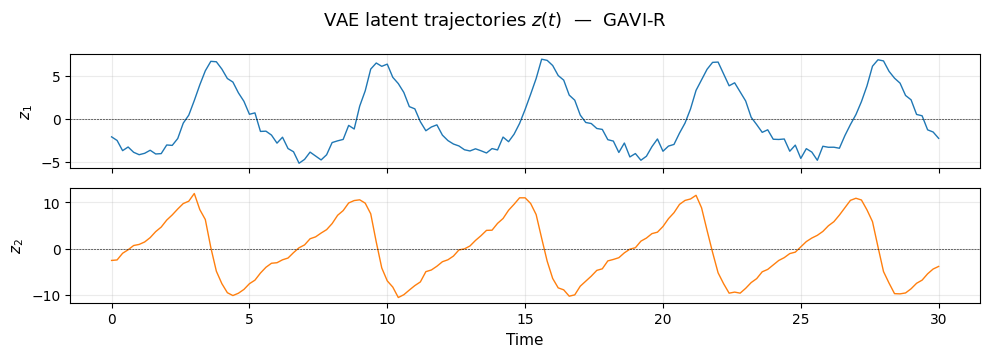

Figure saved to: gavi_reconstruct_R/latent_trajectories.png


In [10]:
import matplotlib.pyplot as plt

latent_np_plot = latent.cpu().numpy()   # (T, latent_dim)

fig, axes = plt.subplots(latent_dim, 1, figsize=(10, 1.8 * latent_dim), sharex=True)
axes = [axes] if latent_dim == 1 else axes

for i, ax in enumerate(axes):
    ax.plot(t, latent_np_plot[:, i], lw=1.0, color=f'C{i}')
    ax.set_ylabel(f'$z_{{{i+1}}}$', fontsize=11)
    ax.axhline(0, color='k', lw=0.4, ls='--')
    ax.grid(True, alpha=0.25)

axes[-1].set_xlabel('Time', fontsize=11)
fig.suptitle('VAE latent trajectories $z(t)$  —  GAVI-R', fontsize=13)
plt.tight_layout()

latent_fig_path = os.path.join(BASEDIR, 'latent_trajectories.png')
plt.savefig(latent_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', latent_fig_path)

---
## Step 3 — Reconstruct from the Saved Model

This step reproduces what you would do in a **separate inference script** after training: load the saved model weights and the latent trajectory, decode back to **B̂** and evaluate the recovered energy.

This separation is important in practice because training is computationally expensive and is only done once, while inference (decoding to reconstruct flow fields) may be repeated many times with different latent codes.

### Reload the QR data and recreate the dataset

The dataset is needed only to provide the correct shape for rebuilding the model architecture and to serve as ground truth for the energy evaluation.

In [11]:
# Re-load Q and B, recreate the scaled dataset (same as step 2)
Q_inf, Rx_inf = pyLOM.NN.GAVI.load(QR_FILE, vars=['Q', 'B'])
print('Q shape:', Q_inf.shape, '  B shape:', Rx_inf.shape)
data_inf, Sscale_inf = pyLOM.NN.GAVI.create_dataset((Rx_inf,), scale='max')
print('Scale factor |B|_max:', Sscale_inf.item())

Q shape: (89351, 80)   B shape: (80, 151)
Scale factor |B|_max: 39.16883850097656


### Load the trained VAE

`load_vae_R` rebuilds the exact same architecture as `vae_R` (same defaults) and loads the saved weights from `gavi_R_latent_<latent_dim>.pth`. The model is set to `eval()` mode automatically.

In [12]:
vae_loaded = pyLOM.NN.GAVI.load_vae_R(data_inf, latent_dim, BASEDIR=BASEDIR)
print('Loaded model from:', os.path.join(BASEDIR, 'gavi_R_latent_%i.pth' % latent_dim))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv1d-1               [-1, 64, 40]             320
            Conv1d-2              [-1, 128, 20]          32,896
            Conv1d-3              [-1, 256, 10]         131,328
           Flatten-4                 [-1, 2560]               0
            Linear-5                   [-1, 32]          81,952
            Linear-6                    [-1, 2]              66
            Linear-7                    [-1, 2]              66
         Encoder1D-8         [[-1, 2], [-1, 2]]               0
            Linear-9                   [-1, 32]              96
           Linear-10                 [-1, 2560]          84,480
  ConvTranspose1d-11              [-1, 128, 20]         131,200
  ConvTranspose1d-12               [-1, 64, 40]          32,832
  ConvTranspose1d-13                [-1, 1, 80]             257
        Decoder1D-14                [-1

### Decode from the latent space and evaluate energy

The saved latent trajectory `z(t)` is loaded and passed through the decoder to obtain **B̂**. The recovered energy on the x-velocity component is then computed and printed.

In [13]:
# Load the latent trajectory saved in step 2
latent_np = np.load(os.path.join(BASEDIR, 'latent_%i.npy' % latent_dim))
print('Latent trajectory shape:', latent_np.shape, ' (T × latent_dim)')

# Decode: map z(t) → B̂(t)
with torch.no_grad():
    z   = torch.tensor(latent_np, dtype=torch.float32, device=pyLOM.NN.DEVICE)
    dec = vae_loaded.decode(z)   # shape: (T, channels, k)

# Recovered energy
energy_x_inf = pyLOM.NN.GAVI.energy(data_inf, dec, 0)
pyLOM.pprint(0, 'Recovered energy %s (from loaded model): {:.2f}%%'.format(energy_x_inf * 100) % VARIABLE, flush=True)

Latent trajectory shape: (151, 2)  (T × latent_dim)
Recovered energy VELOX (from loaded model): 99.19%


/home/ubuntu/Tutorials/pyLOM/pyLowOrder/pyLOM/NN/architectures/autoencoders.py:780: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  zt = torch.tensor(z, dtype=torch.float32, device=self._device)


### Velocity field reconstruction via Q @ B̂

The full flow field can be recovered as:

$$\hat{\mathbf{X}} = \mathbf{Q}\,\hat{\mathbf{B}} + \bar{\mathbf{x}}\,\mathbf{1}^\top$$

where **Q** (spatial modes) and the temporal mean $\bar{\mathbf{x}}$ come from Step 1, and **B̂** is obtained by unscaling the decoder output with the same `Sscale` used during training.

We plot the original and reconstructed streamwise velocity at the first snapshot for a visual comparison.

Reconstructed field shape: (89351, 151)


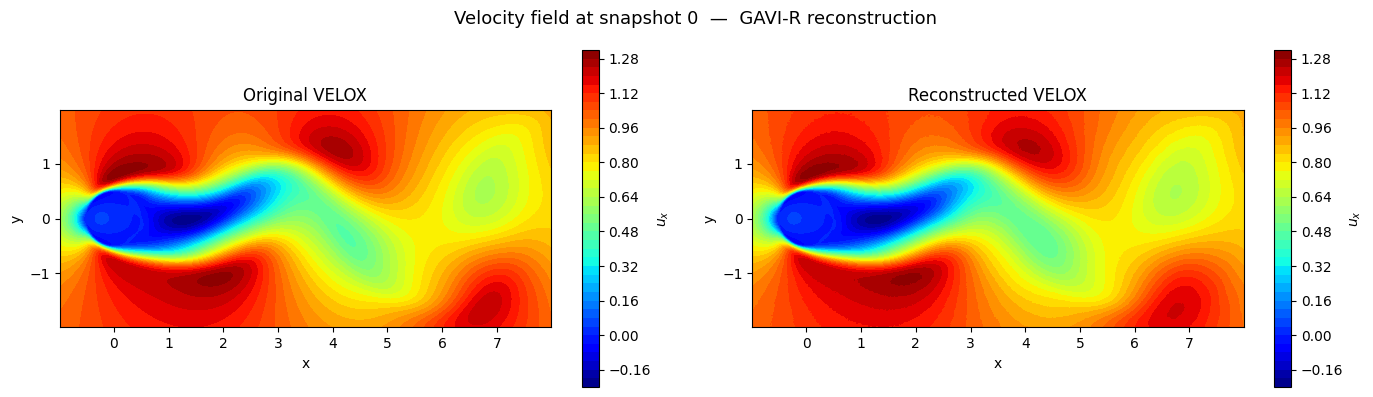

Figure saved to: gavi_reconstruct_R/reconstruction_snapshot0.png


In [14]:
# --- Reconstruct full velocity field ---
# dec shape: (T, channels=1, k)  — still in original scale (scaled by Sscale_inf)
# dec shape: (inp_chan, k, T) — dec[channel] gives (k, T) directly
B_hat = Sscale_inf.item() * dec[0]  # (k, T)
X_rec = Q_inf @ B_hat + Xm[:, np.newaxis]                           # (npoints, T)
print('Reconstructed field shape:', X_rec.shape)

# Load mesh + dataset for plotting (needs xyz coordinates)
m_vis = pyLOM.Mesh.load(DATAFILE)
d_vis = pyLOM.Dataset.load(DATAFILE, ptable=m_vis.partition_table)
d_vis.add_field('VELOX_rec', 1, X_rec)

# --- Plot: original vs reconstructed at snapshot 0 ---
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

x_pts = d_vis.xyz[:, 0]   # dataset coordinates (89351 pts) — matches field data
y_pts = d_vis.xyz[:, 1]

for ax, (label, field) in zip(axes, [('Original VELOX', 'VELOX'), ('Reconstructed VELOX', 'VELOX_rec')]):
    data_plot = d_vis[field][:, 0]          # spatial field at t=0
    sc = ax.tricontourf(x_pts, y_pts, data_plot,
                        levels=50, cmap='jet')
    plt.colorbar(sc, ax=ax, label='$u_x$')
    ax.set_title(label, fontsize=12)
    ax.set_xlabel('x')
    ax.set_ylabel('y')
    ax.set_aspect('equal')

fig.suptitle('Velocity field at snapshot 0  —  GAVI-R reconstruction', fontsize=13)
plt.tight_layout()

recon_fig_path = os.path.join(BASEDIR, 'reconstruction_snapshot0.png')
plt.savefig(recon_fig_path, dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to:', recon_fig_path)

---
## Timing summary

`pyLOM.cr_info()` prints a breakdown of wall-clock time spent in each instrumented function across all three steps.

In [15]:
pyLOM.cr_info()


cr_info (mpi size: 1):
name GAVI.vae_R                     n         1 tmin 1.285524e+01 tmax 1.285524e+01 tavg 1.285524e+01 tsum 1.285524e+01
name VAE.fit                        n         1 tmin 1.267070e+01 tmax 1.267070e+01 tavg 1.267070e+01 tsum 1.267070e+01
name Dataset.load                   n         2 tmin 2.502900e-01 tmax 2.510520e-01 tavg 2.506710e-01 tsum 5.013420e-01
name h5IO.load_dset                 n         2 tmin 2.502459e-01 tmax 2.509941e-01 tavg 2.506200e-01 tsum 5.012400e-01
name GAVI.QR                        n         1 tmin 2.995343e-01 tmax 2.995343e-01 tavg 2.995343e-01 tsum 2.995343e-01
name math.randomized_qr             n         1 tmin 2.638214e-01 tmax 2.638214e-01 tavg 2.638214e-01 tsum 2.638214e-01
name math.tsqr                      n         2 tmin 2.322593e-03 tmax 9.831310e-02 tavg 5.031785e-02 tsum 1.006357e-01
name math.qr                        n         2 tmin 2.035490e-03 tmax 9.672774e-02 tavg 4.938161e-02 tsum 9.876323e-02
name GAVI.save_Q